In [1]:
import pandas as pd
from tnwater import plot_id
import seaborn as sns
import matplotlib.pyplot as plt

# read in data
df = pd.read_csv('../../data/cleaned_data.csv')



In [ ]:
# only retain ids that have more than one observation
#df = df.groupby('id').filter(lambda x: len(x) > 1)

In [2]:

# rename some of the columns so the names are not as long

# Modify the original DataFrame directly
df.rename(columns={'inorganic_nitrogen_(nitrate_and_nitrite)_total': 'no3_no2',
            'chlorophyll_a_total': 'chla',
            'phosphorus_total': 'tp',
            'total_suspended_solids_suspended': 'tss'}, inplace=True)


In [3]:
df.columns

Index(['date_time', 'site', 'id', 'position', 'year', 'month', 'decimal_date',
       'latitude', 'longitude', 'distance_from_centerline_km',
       'total_distance', 'activity_depth_value', 'ammonia_total',
       'ammonium_total', 'chla', 'chlorophyll_b_fixed', 'chlorophyll_c_fixed',
       'no3_no2', 'kjeldahl_nitrogen_total', 'nitrogen_total',
       'organic_nitrogen_total', 'orthophosphate_dissolved',
       'phosphorus_dissolved', 'tp', 'tss', 'turbidity_total', 'ph_total'],
      dtype='object')

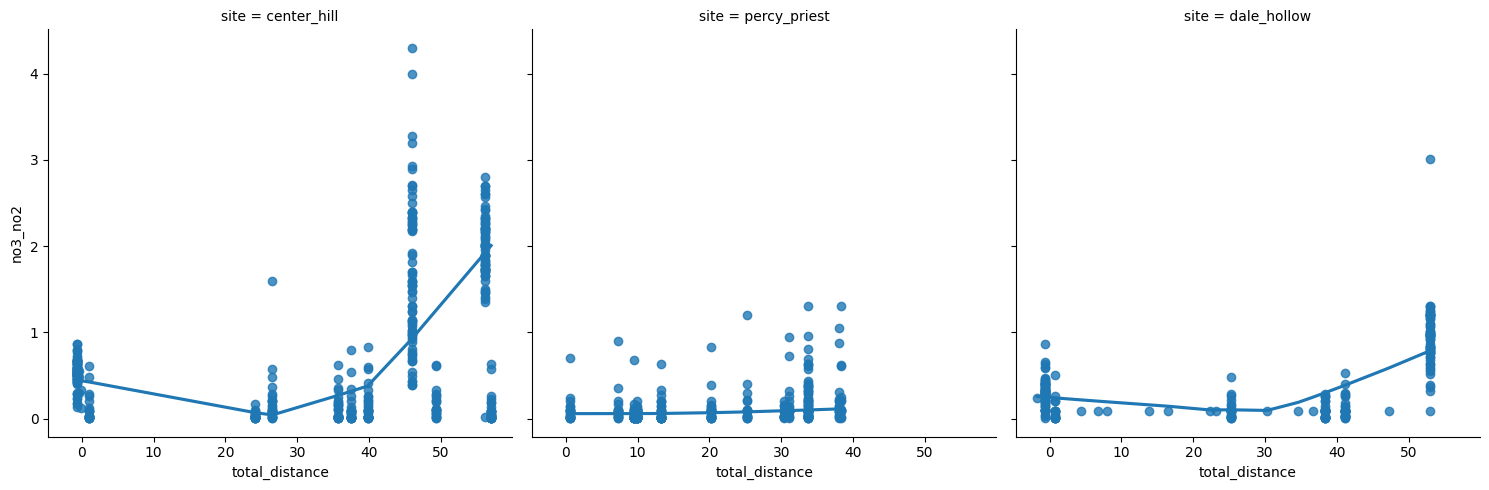

In [7]:

sns.lmplot(
    data=df,
    x='total_distance',
    y='no3_no2',
    col='site',
    lowess=True   # smoother line
)


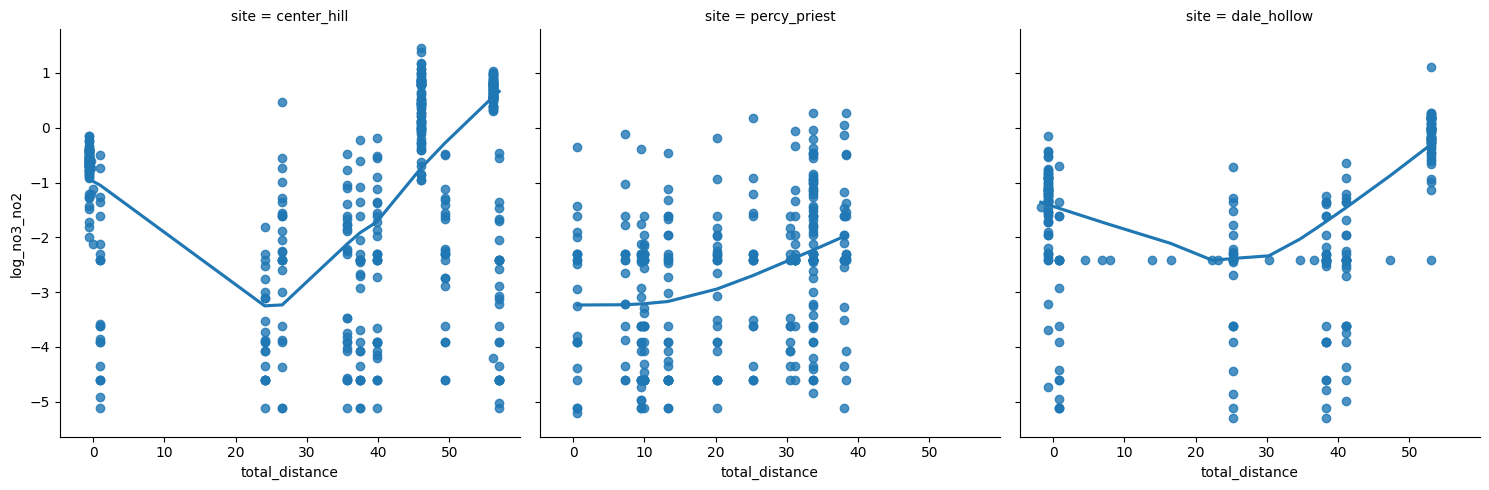

In [8]:
import numpy as np

sub_df=df
sub_df['log_no3_no2'] = np.log(sub_df['no3_no2'])

sns.lmplot(
    data=sub_df,
    x='total_distance',
    y='log_no3_no2',
    col='site',
    lowess=True   # smoother line
)

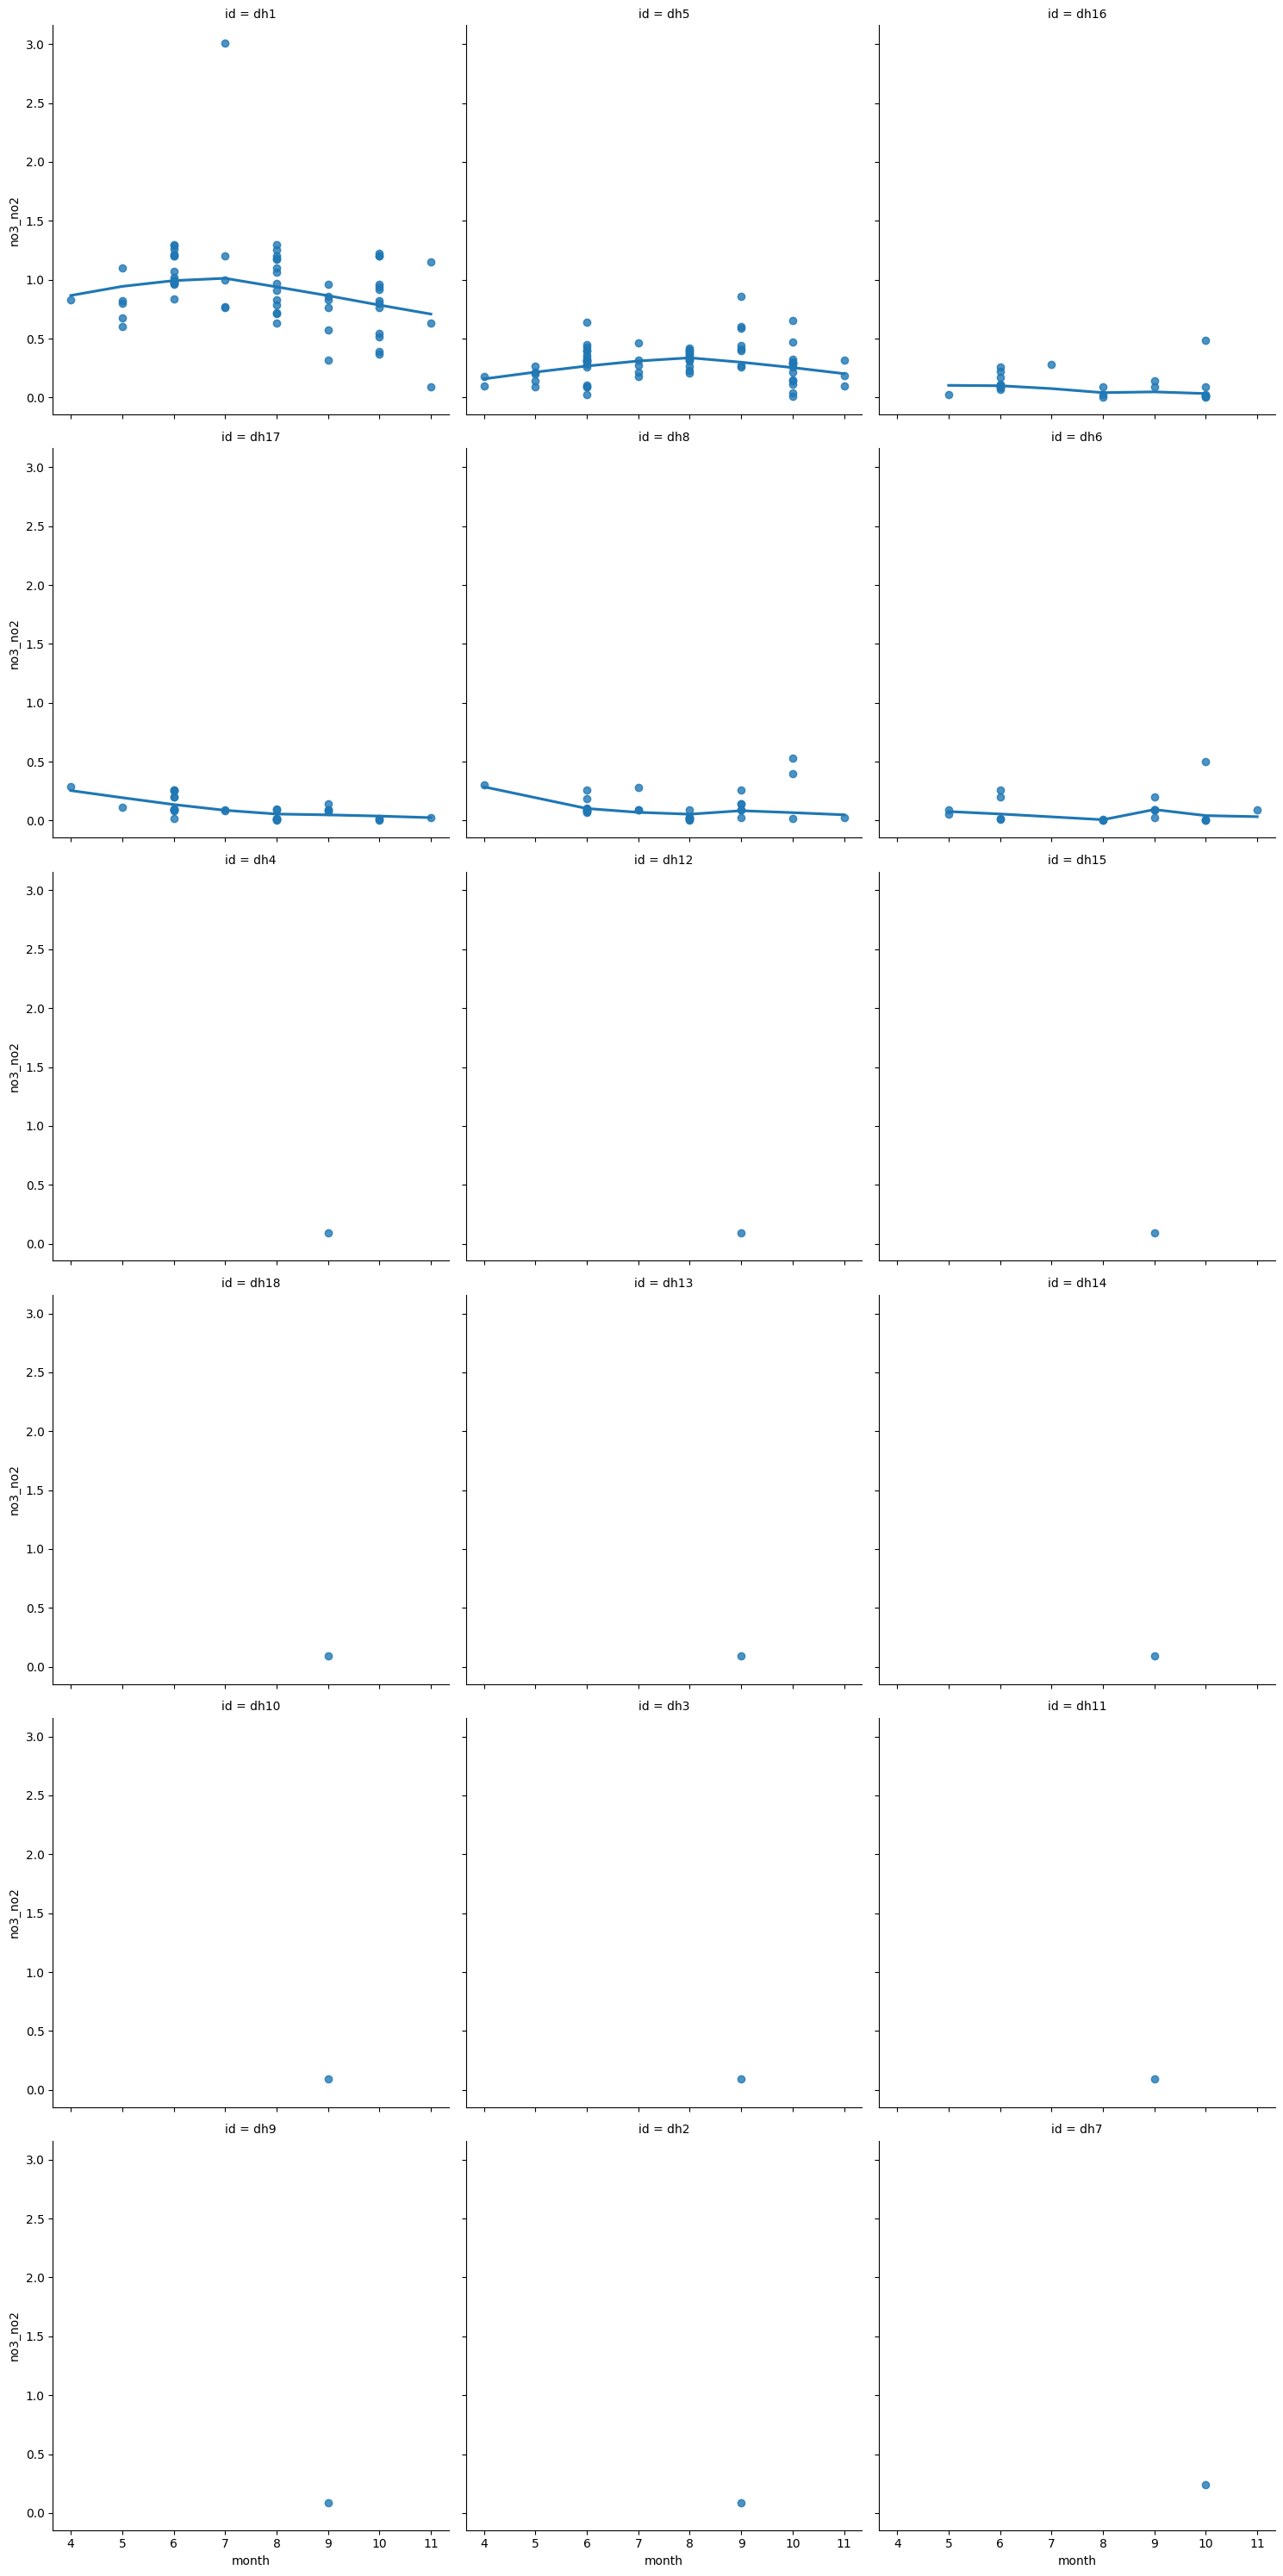

In [12]:
dh_sub = df[df['site'] == 'dale_hollow']

sns.lmplot(
    data=dh_sub,
    x='month',
    y='no3_no2',
    col='id',
    col_wrap=3,   # 3 columns per row
    lowess=True   # smoother line
)

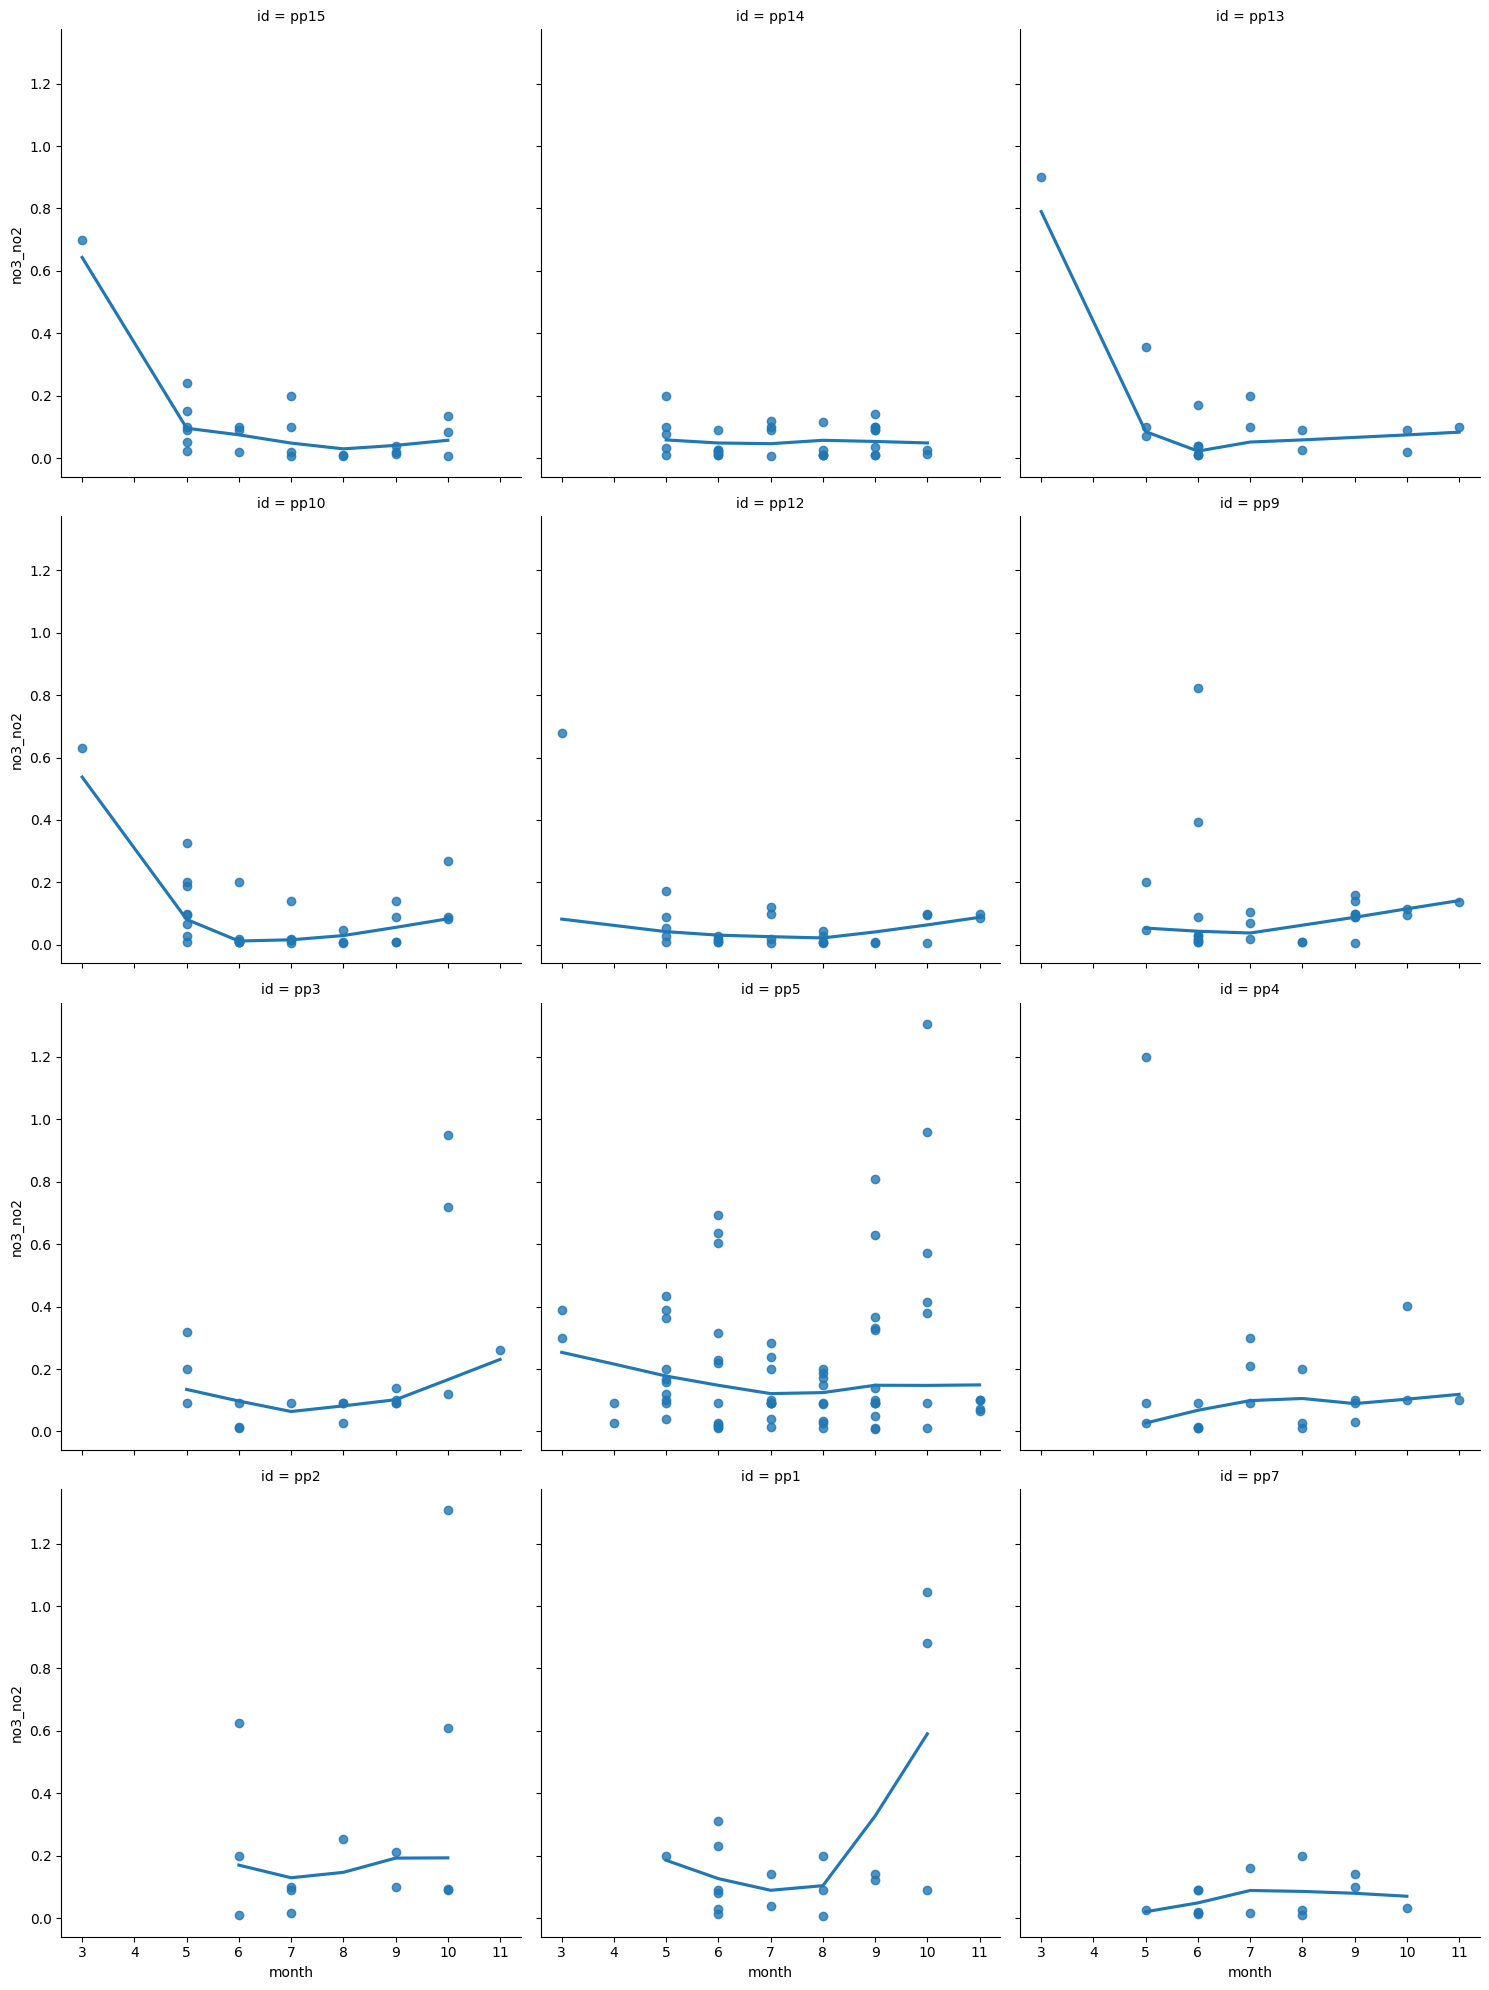

In [13]:
pp_sub = df[df['site'] == 'percy_priest']

sns.lmplot(
    data=pp_sub,
    x='month',
    y='no3_no2',
    col='id',
    col_wrap=3,   # 3 columns per row
    lowess=True   # smoother line
)

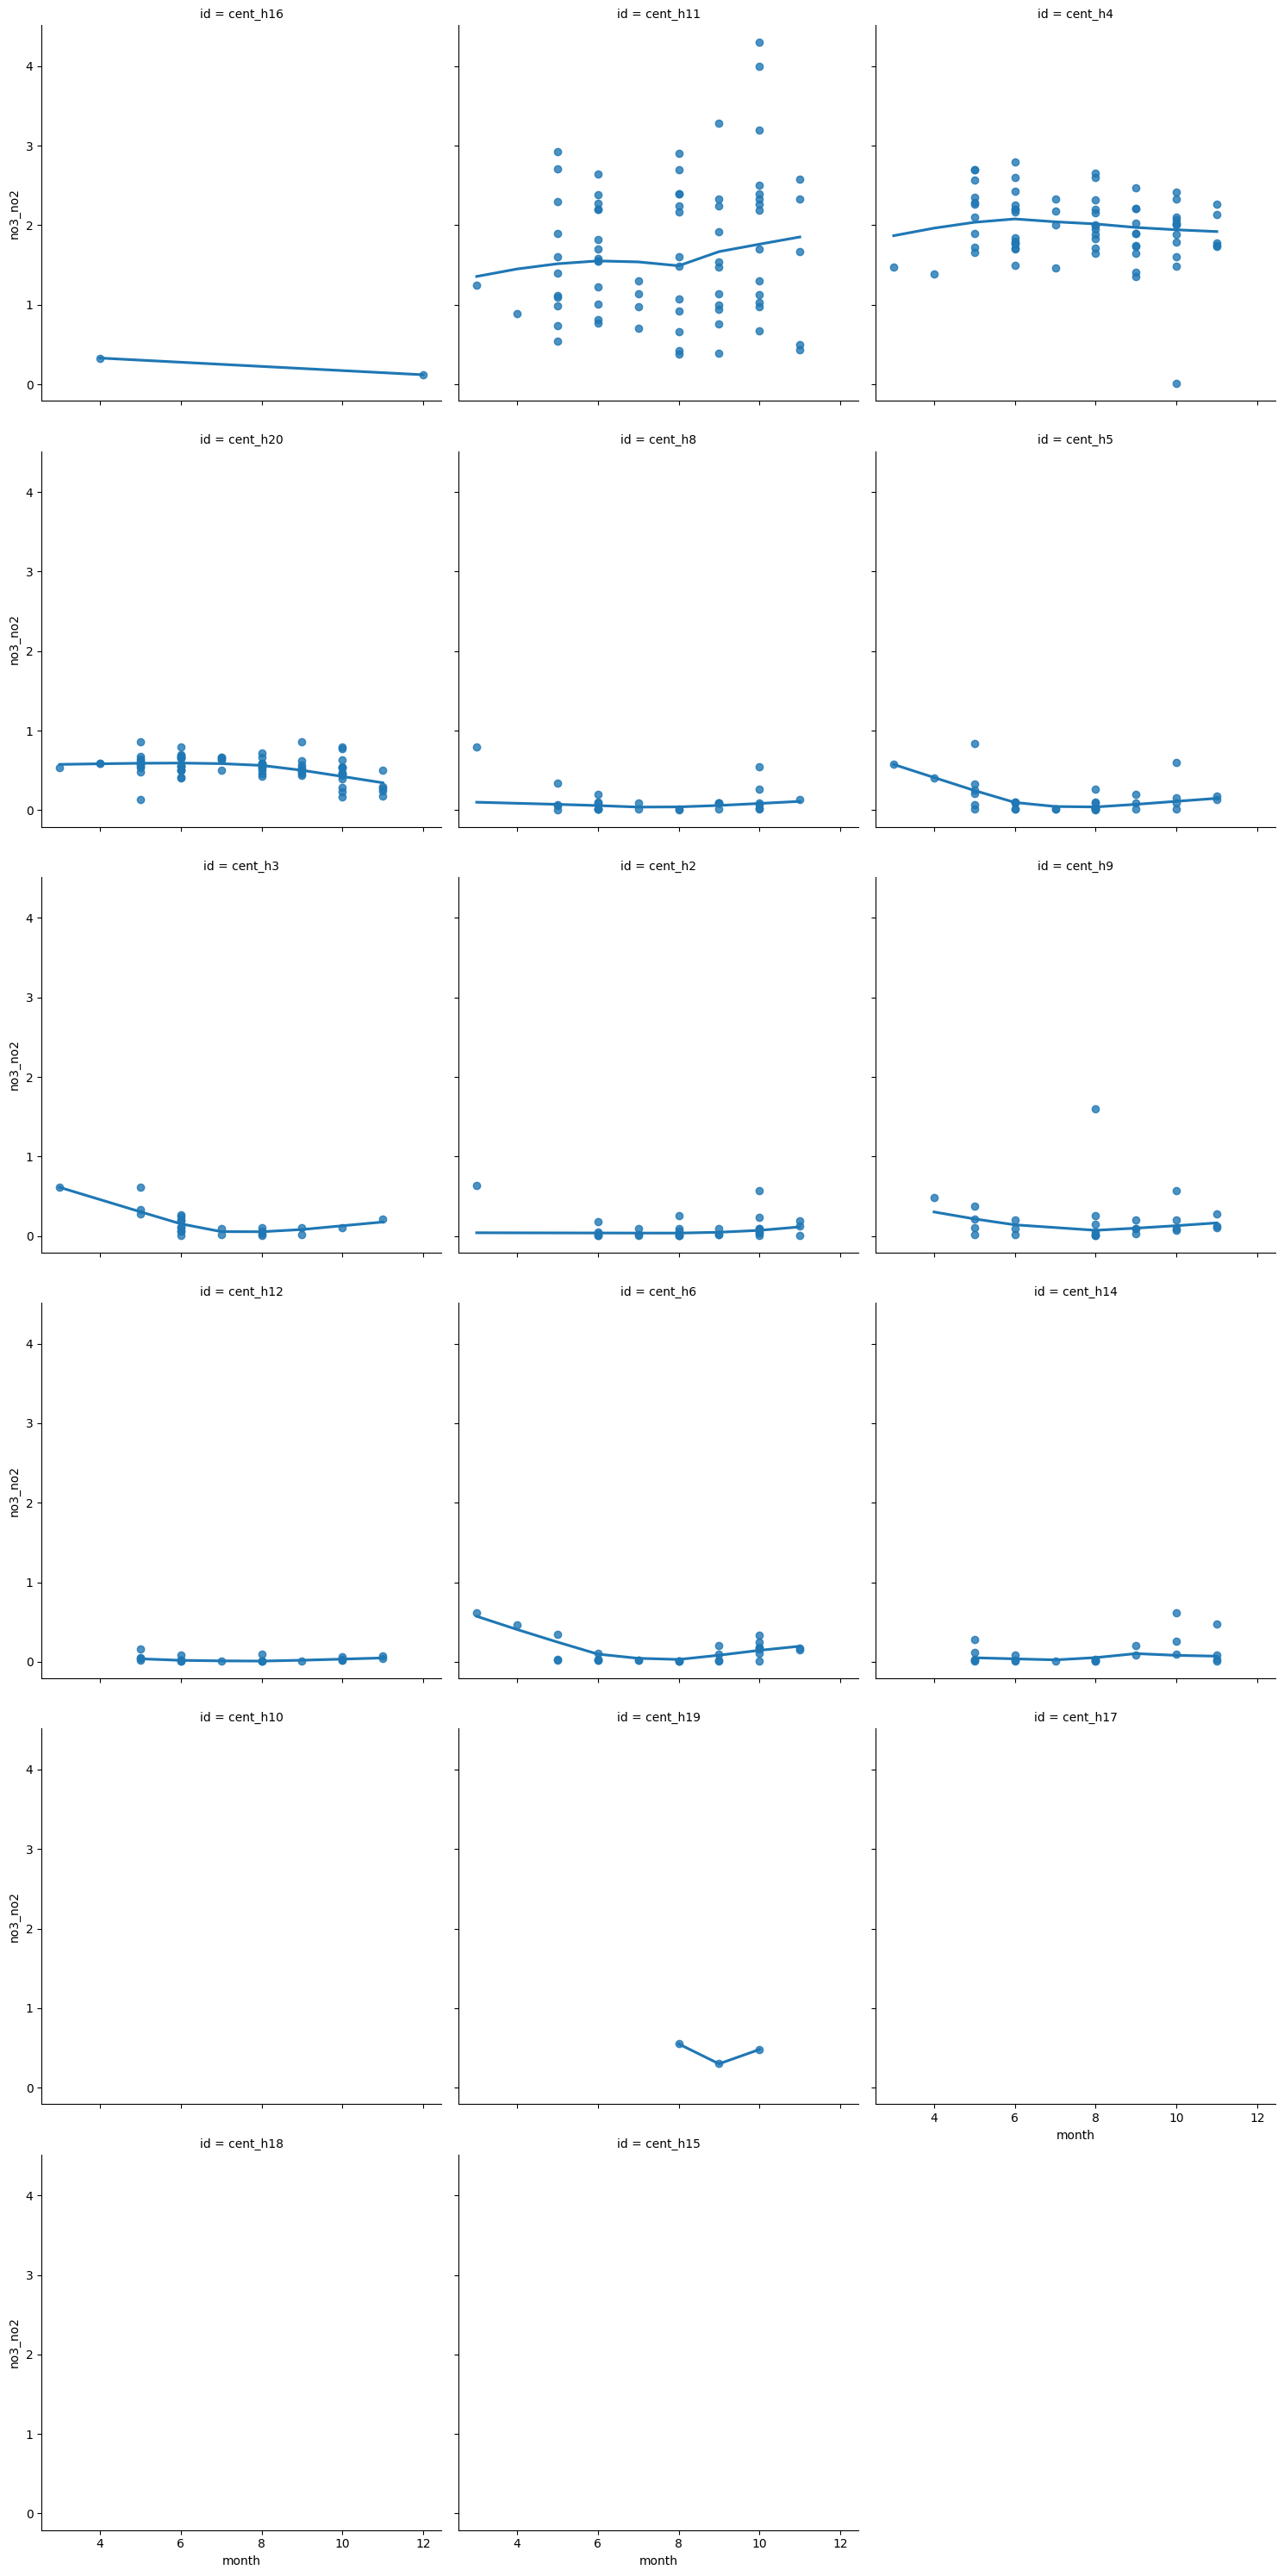

In [14]:
ch_sub = df[df['site'] == 'center_hill']

sns.lmplot(
    data=ch_sub,
    x='month',
    y='no3_no2',
    col='id',
    col_wrap=3,   # 3 columns per row
    lowess=True   # smoother line
)

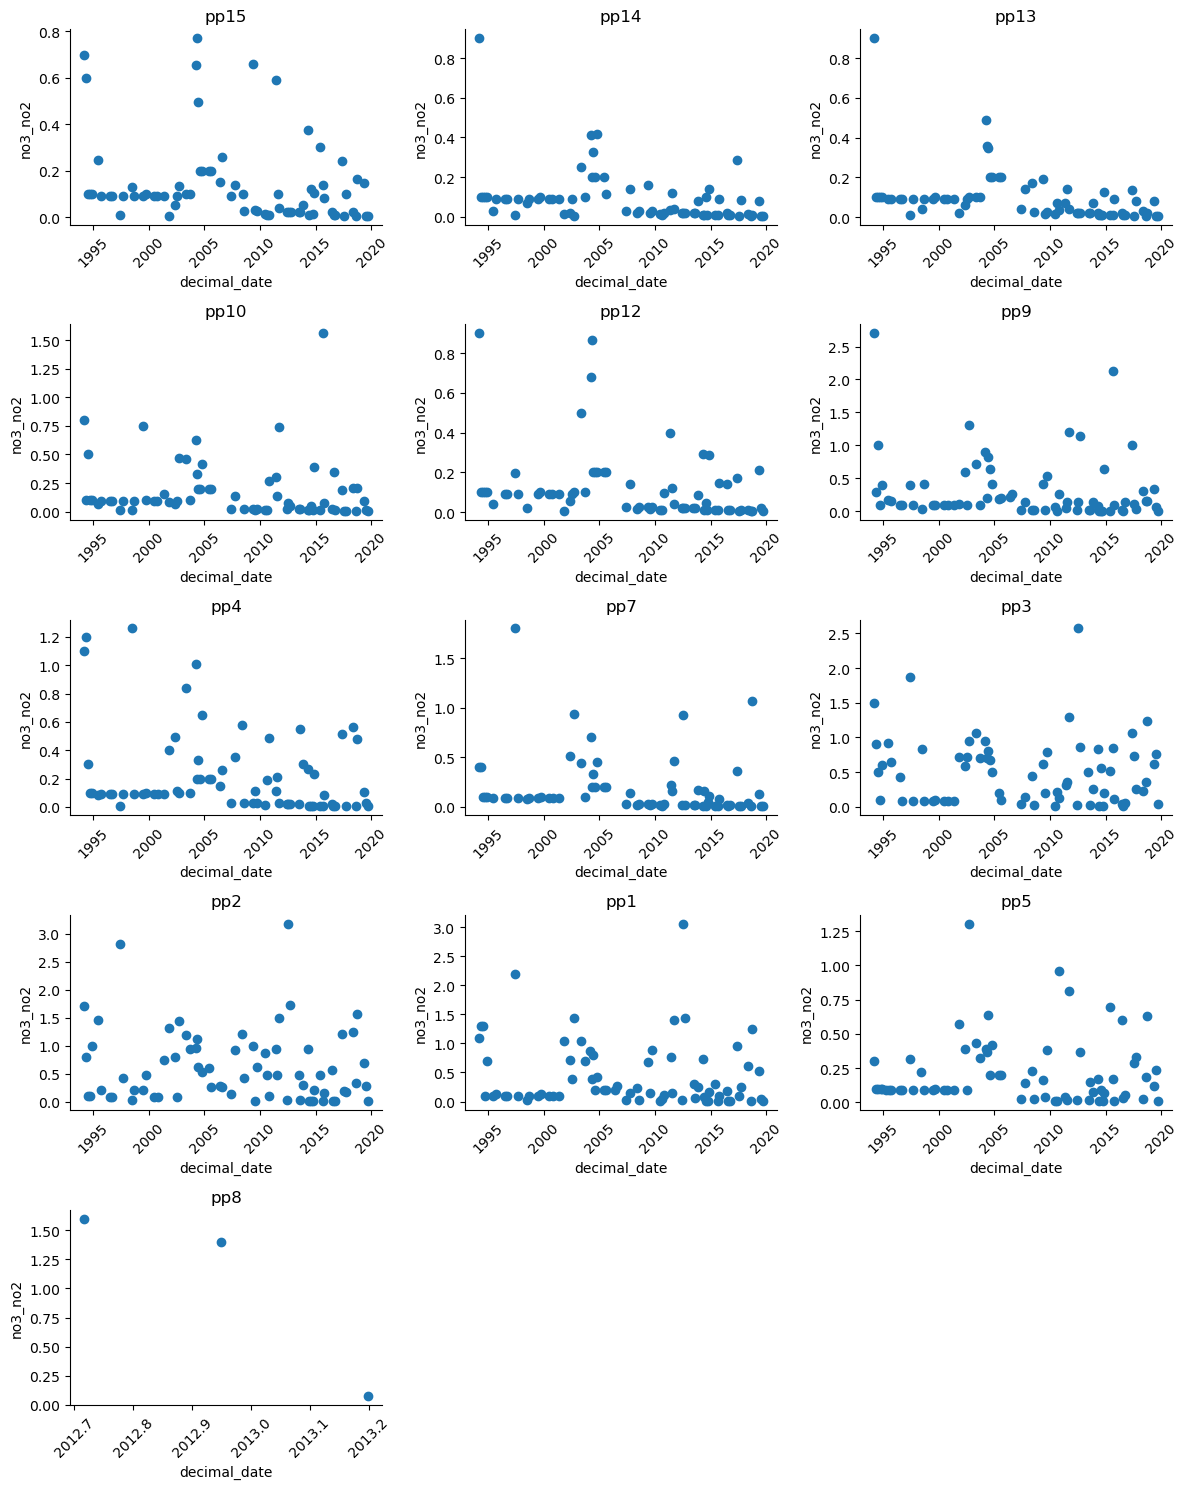

In [16]:
plot_id(df, var='no3_no2', site_col='site', site_name='percy_priest',
        x_col='decimal_date', y_col='no3_no2', kind='scatter')

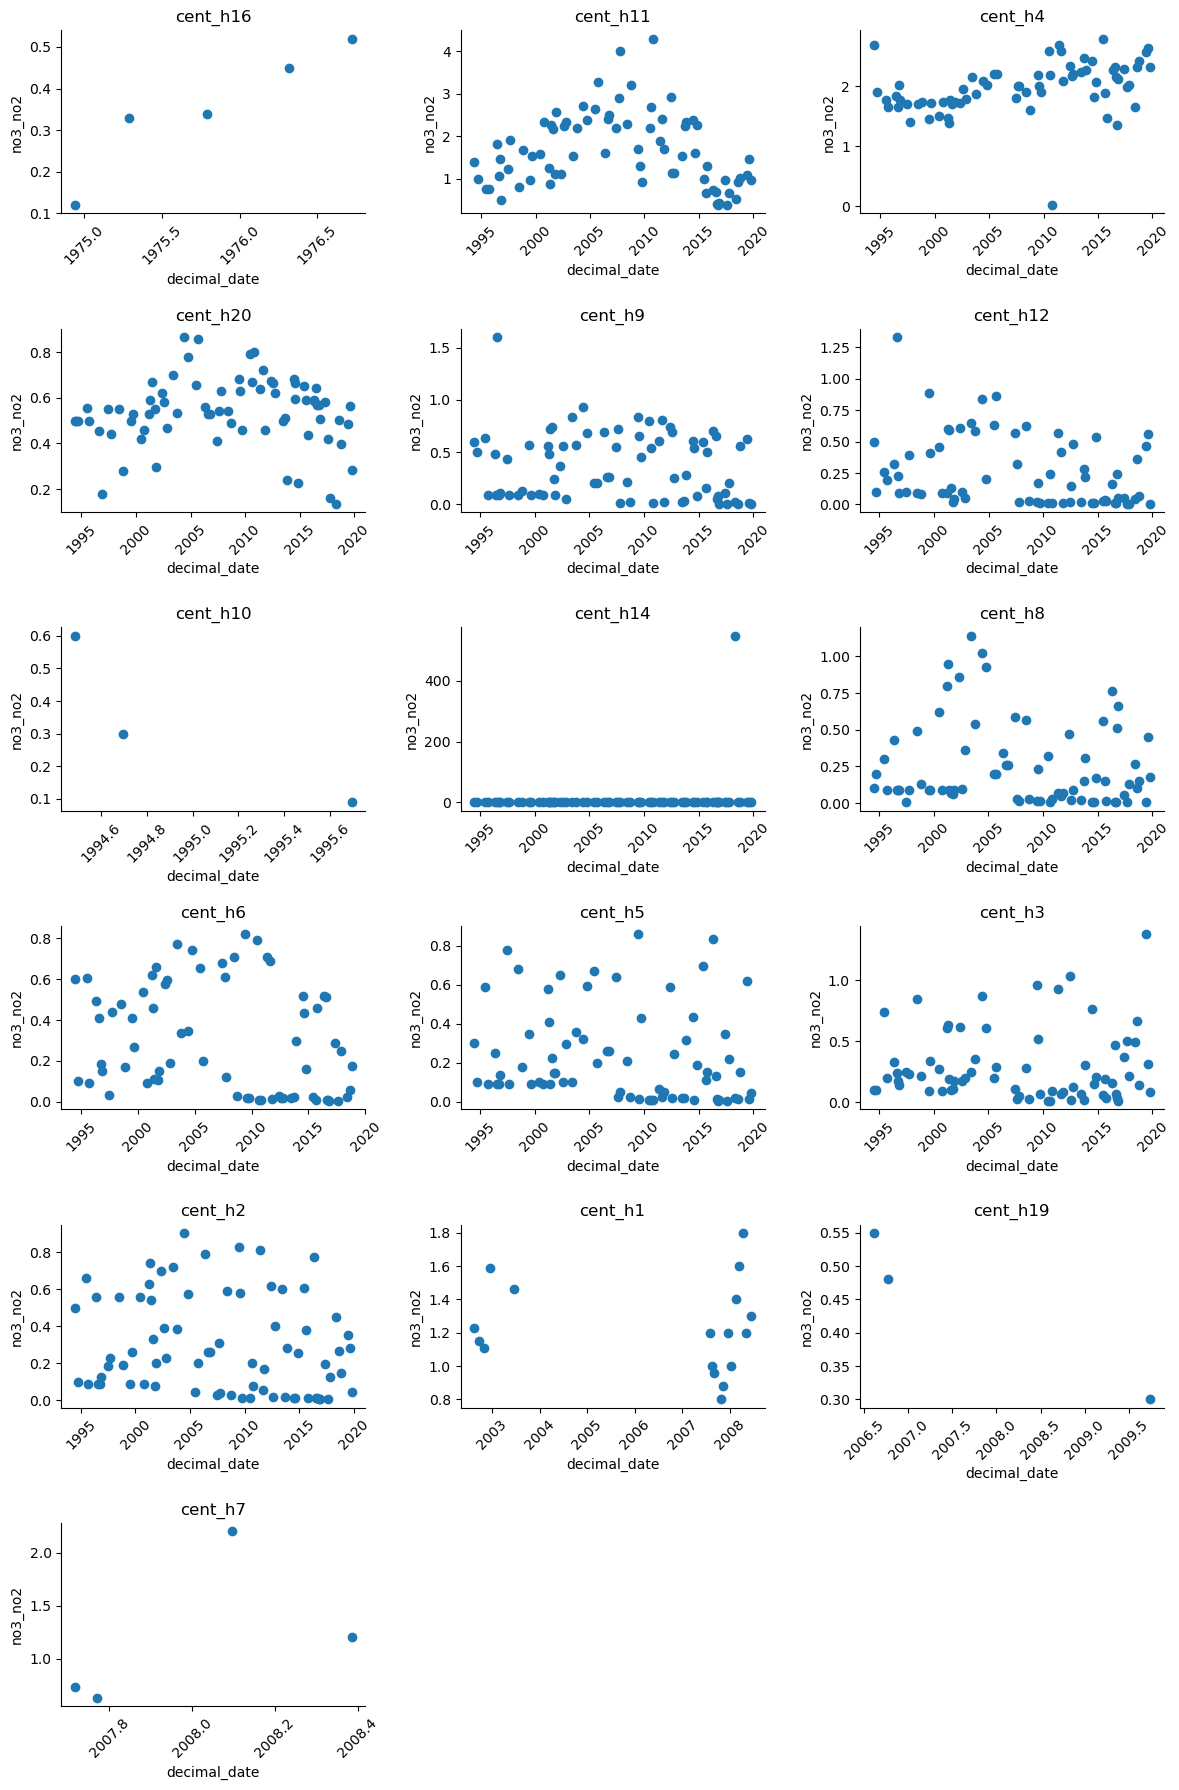

In [17]:
plot_id(df, var='no3_no2', site_col='site', site_name='center_hill',
        x_col='decimal_date', y_col='no3_no2', kind='scatter')

In [15]:
# Returns a Series with group labels as the index
df.groupby('id').size()

id
cent_h10      1
cent_h11     74
cent_h12     66
cent_h14     69
cent_h15      5
cent_h16      2
cent_h17      9
cent_h18      9
cent_h19      4
cent_h2      68
cent_h20    101
cent_h3      42
cent_h4      72
cent_h5      65
cent_h6      61
cent_h8      64
cent_h9      65
dh1          64
dh10          1
dh11          1
dh12          1
dh13          1
dh14          1
dh15          1
dh16         64
dh17         64
dh18          1
dh2           1
dh3           1
dh4           1
dh5          68
dh6          59
dh7           1
dh8          68
dh9           1
pp1          31
pp10         62
pp12         63
pp13         29
pp14         56
pp15         62
pp2          26
pp3          47
pp4          31
pp5          71
pp7          26
pp9          63
dtype: int64

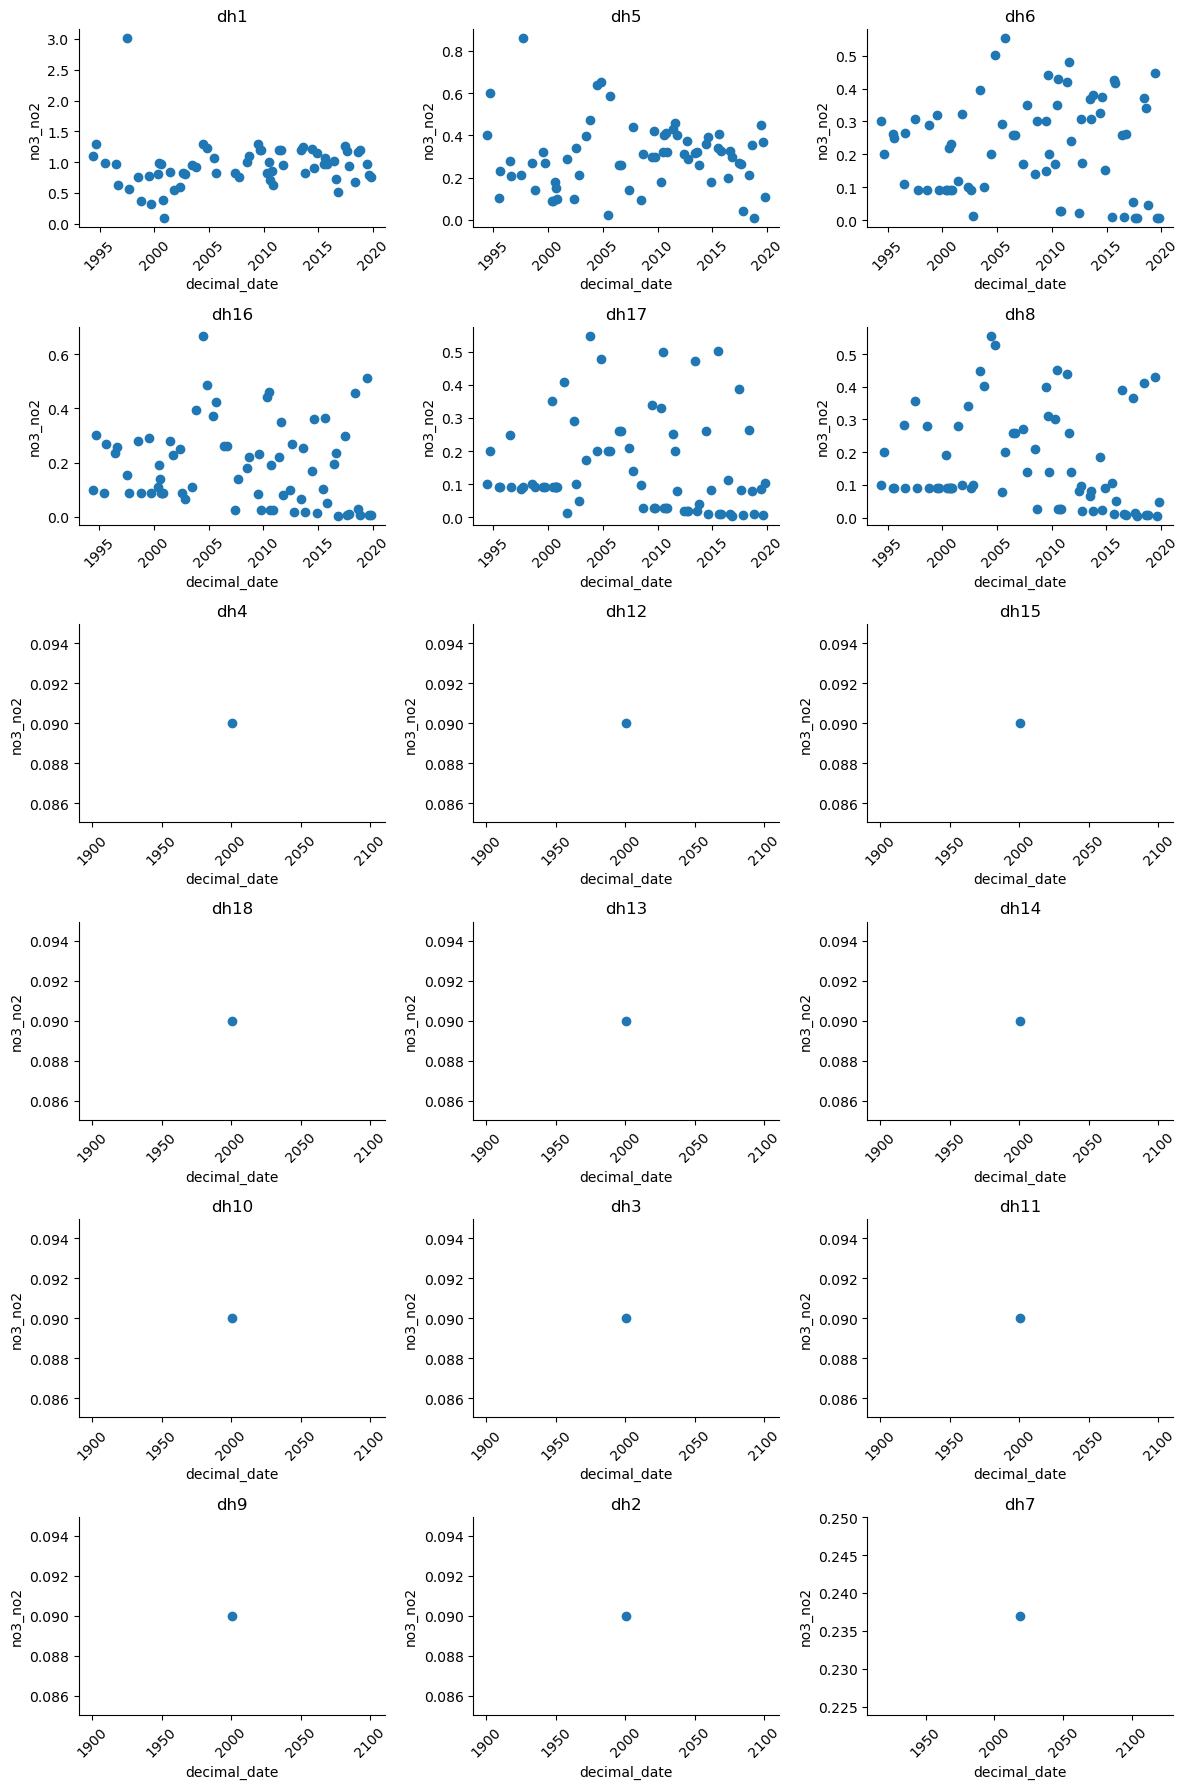

In [19]:
plot_id(df, var='no3_no2', site_col='site', site_name='dale_hollow',
        x_col='decimal_date', y_col='no3_no2', kind='scatter')

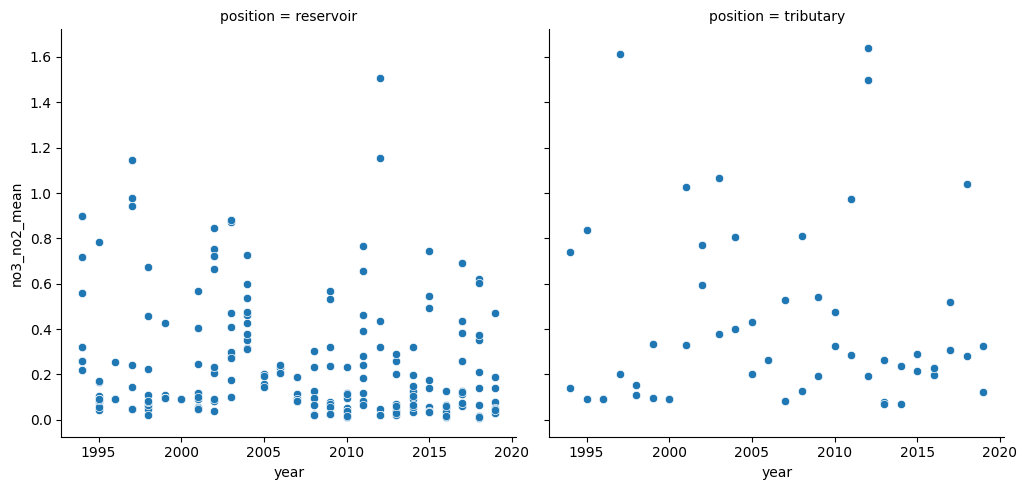

In [7]:
(df[df['site'] == 'percy_priest']
    .groupby(['id', 'position', 'year'])['no3_no2']
    .agg(no3_no2_mean='mean')
    .reset_index()
    .pipe(lambda d: sns.relplot(
        data=d,
        x='year',
        y='no3_no2_mean',
        col='position',
        col_wrap=4   # 👈 controls number of columns
    ))
)

plt.show()

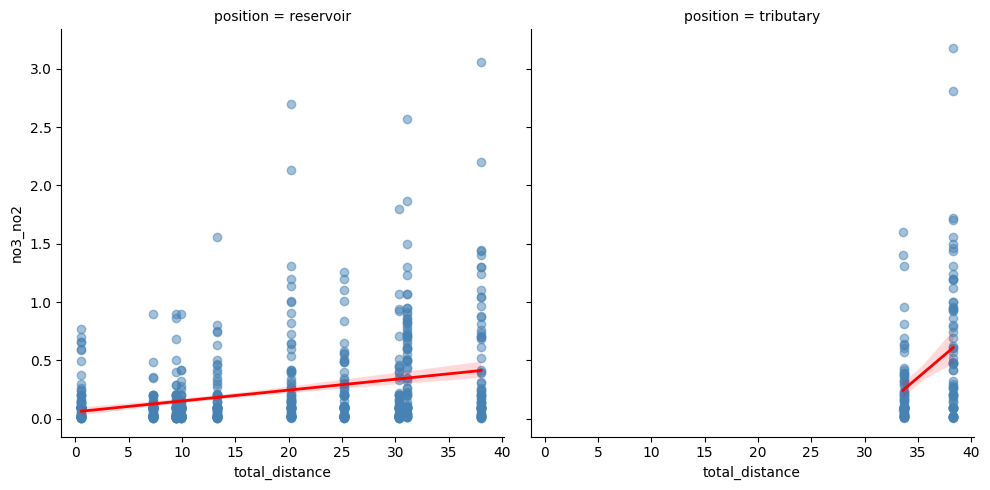

In [12]:
(df[df['site'] == 'percy_priest']
    .pipe(lambda d: sns.lmplot(
        data=d, x='total_distance', 
        y='no3_no2',
        col='position',
        scatter=True,       # show points too
        ci=95,               # confidence interval, like geom_smooth's se=TRUE
        line_kws={'color': 'red', 'linewidth': 2},       # regression line  - control the line color, linesize etc.
        scatter_kws={'color': 'steelblue', 'alpha': 0.5} # scatter points
    ))

)


In [15]:
import pingouin as pg
 
reservior_positions_only = df[df['position'] == 'reservoir']

pg.pairwise_corr(reservior_positions_only, columns=['no3_no2', 'total_distance'], method='pearson')

,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,no3_no2,total_distance,pearson,two-sided,1575,-0.036673,"[-0.09, 0.01]",0.145744,0.091,0.307124


In [ ]:
tributary_positions_only = df[df['position'] == 'tributary']

pg.pairwise_corr(tributary_positions_only, columns=['no3_no2', 'total_distance'], method='pearson')

# wow nutrient content in tribs is really correlated with distance total distance to the dam

,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,no3_no2,total_distance,pearson,two-sided,371,0.563711,"[0.49, 0.63]",1.678168e-32,1.943e+29,1.0


In [5]:
a = (df[df['site'] == 'percy_priest']
    .groupby(['id', 'year'])['no3_no2']
    .agg('mean')
    .reset_index())

In [8]:
df.columns

Index(['date_time', 'site', 'id', 'position', 'year', 'month', 'decimal_date',
       'latitude', 'longitude', 'distance_from_centerline_km',
       'total_distance', 'ammonia_total', 'ammonium_total', 'chla',
       'chlorophyll_b_fixed', 'chlorophyll_c_fixed',
       'dissolved_oxygen_(do)_dissolved', 'no3_no2', 'kjeldahl_nitrogen_total',
       'nitrate_total', 'nitrite_total', 'nitrogen_total',
       'organic_nitrogen_total', 'organic_phosphorus_total',
       'orthophosphate_dissolved', 'orthophosphate_total',
       'phosphorus_dissolved', 'tp', 'tss', 'turbidity_total', 'ph_total'],
      dtype='object')